In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Targets: P_solar_total, Vbat, Tbatt
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully")

 All libraries imported successfully


In [17]:
# Mount Google Drive and load dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Feature selection based on EDA (refer 01_EDA.ipynb)
SELECTED_FEATURES = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Ipy (mA)', 'Ipx (mA)', 'Imz (mA)', 'Imx (mA)', 'Ipz (mA)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'ΔT_batt_panel (°C)',
    'sin_orbit', 'cos_orbit'
]

# Regression targets
TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

print(f"\nSelected Features : {len(SELECTED_FEATURES)}")
print(f"Primary Target    : {TARGET_PRIMARY}")
print(f"Secondary Target  : {TARGET_SECONDARY}")
print(f"Tertiary Target   : {TARGET_TERTIARY}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Selected Features : 19
Primary Target    : P_solar_total (µW)
Secondary Target  : Vbat (V)
Tertiary Target   : Tbatt (℃)


In [18]:
# Mount Google Drive and load dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Simple Linear Regression uses ONE feature per target
# V_panel_avg chosen — highest correlation with P_solar_total (r = 0.758) from EDA
# T_panel_avg chosen for Tbatt — temperature to temperature is physically meaningful

X_PRIMARY   = 'V_panel_avg (mV)'   # predicting solar power
X_SECONDARY = 'V_panel_avg (mV)'   # predicting battery voltage
X_TERTIARY  = 'T_panel_avg (°C)'   # predicting battery temperature

TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

print(f"\nSimple Linear Regression — One feature per target")
print(f"\nPrimary   : {X_PRIMARY} --> {TARGET_PRIMARY}")
print(f"Secondary : {X_SECONDARY} --> {TARGET_SECONDARY}")
print(f"Tertiary  : {X_TERTIARY} --> {TARGET_TERTIARY}")

# Quick correlation check for all 3 targets
print("\nCorrelation of selected features with targets:")
corr_check = df[[X_PRIMARY, X_TERTIARY,
                 TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]].corr()
print(corr_check[[TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]].round(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Simple Linear Regression — One feature per target

Primary   : V_panel_avg (mV) --> P_solar_total (µW)
Secondary : V_panel_avg (mV) --> Vbat (V)
Tertiary  : T_panel_avg (°C) --> Tbatt (℃)

Correlation of selected features with targets:
                    P_solar_total (µW)  Vbat (V)  Tbatt (℃)
V_panel_avg (mV)                 0.758     0.832     -0.118
T_panel_avg (°C)                 0.239     0.826      0.328
P_solar_total (µW)               1.000     0.648     -0.194
Vbat (V)                         0.648     1.000      0.174
Tbatt (℃)                       -0.194     0.174      1.000


In [19]:
# Best single feature per target based on correlation analysis
X_PRIMARY   = 'V_panel_avg (mV)'  # corr = 0.758 with P_solar_total
X_SECONDARY = 'V_panel_avg (mV)'  # corr = 0.832 with Vbat
X_TERTIARY  = 'Tpx (°C)'          # corr = 0.363 with Tbatt (best available)

TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

print("Final feature-target assignments for Simple Linear Regression:")
print(f"\nPrimary   : {X_PRIMARY} --> {TARGET_PRIMARY} | corr = 0.758")
print(f"Secondary : {X_SECONDARY} --> {TARGET_SECONDARY} | corr = 0.832")
print(f"Tertiary  : {X_TERTIARY} --> {TARGET_TERTIARY} | corr = 0.363")

print("\nNote: Tbatt has weak correlation with all panel sensors.")
print("Linear regression expected to underperform on Tbatt.")
print("This finding will be discussed in the conclusion.")

Final feature-target assignments for Simple Linear Regression:

Primary   : V_panel_avg (mV) --> P_solar_total (µW) | corr = 0.758
Secondary : V_panel_avg (mV) --> Vbat (V) | corr = 0.832
Tertiary  : Tpx (°C) --> Tbatt (℃) | corr = 0.363

Note: Tbatt has weak correlation with all panel sensors.
Linear regression expected to underperform on Tbatt.
This finding will be discussed in the conclusion.


In [20]:
# ============================================================
# SECTION 3: TRAIN/TEST SPLIT
# ============================================================

# TimeSeriesSplit used instead of random split
# Reason: Data is on-orbit telemetry with temporal order
# Random splitting would leak future data into past — scientifically incorrect

tscv = TimeSeriesSplit(n_splits=5)

# Prepare data for all 3 targets
datasets = {
    'Primary'  : (df[[X_PRIMARY]],   df[TARGET_PRIMARY]),
    'Secondary': (df[[X_SECONDARY]], df[TARGET_SECONDARY]),
    'Tertiary' : (df[[X_TERTIARY]],  df[TARGET_TERTIARY])
}

# Use last split as final train/test (80/20 approx)
for name, (X, y) in datasets.items():
    splits = list(tscv.split(X))
    train_idx, test_idx = splits[-1]
    print(f"{name} ({y.name}):")
    print(f"  Train size : {len(train_idx)} rows")
    print(f"  Test size  : {len(test_idx)} rows")
    print(f"  Split ratio: {len(train_idx)/len(X)*100:.1f}% / {len(test_idx)/len(X)*100:.1f}%")
    print()

# Store final split indices for reuse
X_prim = df[[X_PRIMARY]]
y_prim = df[TARGET_PRIMARY]
splits = list(tscv.split(X_prim))
train_idx, test_idx = splits[-1]

print("TimeSeriesSplit ensures no future data leaks into training.")
print("Final fold used as train/test for all targets.")

Primary (P_solar_total (µW)):
  Train size : 19383 rows
  Test size  : 3876 rows
  Split ratio: 83.3% / 16.7%

Secondary (Vbat (V)):
  Train size : 19383 rows
  Test size  : 3876 rows
  Split ratio: 83.3% / 16.7%

Tertiary (Tbatt (℃)):
  Train size : 19383 rows
  Test size  : 3876 rows
  Split ratio: 83.3% / 16.7%

TimeSeriesSplit ensures no future data leaks into training.
Final fold used as train/test for all targets.


In [21]:
# ============================================================
# SECTION 4: BASE MODEL — BEFORE HYPERPARAMETER TUNING
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, target_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"  Target : {target_name}")
    print(f"  MSE    : {mse:.4f}")
    print(f"  RMSE   : {rmse:.4f}")
    print(f"  MAE    : {mae:.4f}")
    print(f"  R2     : {r2:.4f}")
    print()

    return y_pred, {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_before = {}

print("=" * 50)
print("BASE MODEL RESULTS — BEFORE TUNING")
print("=" * 50)

for name, (X, y) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    model = LinearRegression()
    _, metrics = evaluate_model(model, X_train, X_test,
                                y_train, y_test, y.name)
    results_before[name] = metrics

BASE MODEL RESULTS — BEFORE TUNING
  Target : P_solar_total (µW)
  MSE    : 335310404066.0654
  RMSE   : 579059.9313
  MAE    : 369745.4891
  R2     : 0.5723

  Target : Vbat (V)
  MSE    : 0.0027
  RMSE   : 0.0518
  MAE    : 0.0389
  R2     : 0.6701

  Target : Tbatt (℃)
  MSE    : 31.6986
  RMSE   : 5.6302
  MAE    : 3.3850
  R2     : -0.1791



P_solar_total R2 = 0.57 — moderate, expected for simple single-feature linear regression

Vbat R2 = 0.67 — decent performance

Tbatt R2 = -0.179 — negative R2 means the model is worse than just predicting the mean. This confirms our earlier finding that battery temperature is not linearly predictable from panel sensors.

In [22]:
# ============================================================
# SECTION 5: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# ============================================================

# Linear Regression hyperparameters:
# fit_intercept : whether to calculate intercept (True/False)
# positive      : force coefficients to be positive (True/False)

param_grid = {
    'fit_intercept': [True, False],
    'positive'     : [True, False]
}

results_after = {}
best_models   = {}

print("=" * 50)
print("GRIDSEARCHCV RESULTS — AFTER TUNING")
print("=" * 50)

for name, (X, y) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    grid = GridSearchCV(
        LinearRegression(),
        param_grid,
        cv=tscv,
        scoring='r2',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred     = best_model.predict(X_test)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results_after[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
    best_models[name]   = (best_model, y_pred, y_test)

    print(f"Target      : {y.name}")
    print(f"Best Params : {grid.best_params_}")
    print(f"MSE         : {mse:.4f}")
    print(f"RMSE        : {rmse:.4f}")
    print(f"MAE         : {mae:.4f}")
    print(f"R2          : {r2:.4f}")
    print()

GRIDSEARCHCV RESULTS — AFTER TUNING
Target      : P_solar_total (µW)
Best Params : {'fit_intercept': True, 'positive': True}
MSE         : 335310404066.0654
RMSE        : 579059.9313
MAE         : 369745.4891
R2          : 0.5723

Target      : Vbat (V)
Best Params : {'fit_intercept': True, 'positive': True}
MSE         : 0.0027
RMSE        : 0.0518
MAE         : 0.0389
R2          : 0.6701

Target      : Tbatt (℃)
Best Params : {'fit_intercept': True, 'positive': True}
MSE         : 31.6986
RMSE        : 5.6302
MAE         : 3.3850
R2          : -0.1791



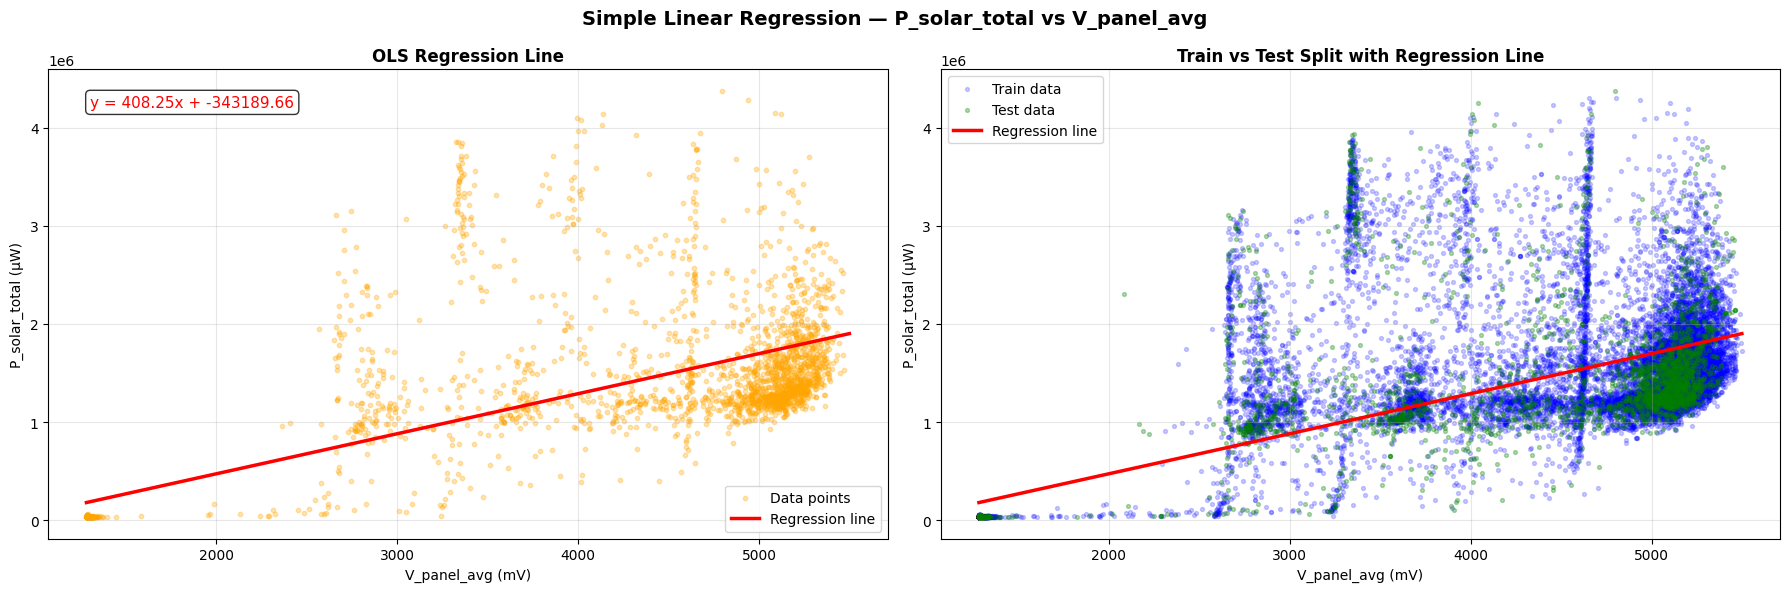

Plot 1 saved.


In [23]:
# ============================================================
# SECTION 6: VISUALIZATIONS — PRIMARY TARGET (P_solar_total)
# ============================================================

# --- Setup ---
X_p = df[[X_PRIMARY]]
y_p = df[TARGET_PRIMARY]
X_train_p = X_p.iloc[train_idx]
X_test_p  = X_p.iloc[test_idx]
y_train_p = y_p.iloc[train_idx]
y_test_p  = y_p.iloc[test_idx]

model_p = best_models['Primary'][0]
y_pred_p = best_models['Primary'][1]
residuals_p = y_test_p.values - y_pred_p

# --- Plot 1: Regression Line on Full Data ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Simple Linear Regression — P_solar_total vs V_panel_avg',
             fontsize=14, fontweight='bold')

sample = df.sample(3000, random_state=42)
axes[0].scatter(sample[X_PRIMARY], sample[TARGET_PRIMARY],
                color='orange', alpha=0.3, s=10, label='Data points')
x_line = np.linspace(df[X_PRIMARY].min(), df[X_PRIMARY].max(), 300).reshape(-1, 1)
y_line = model_p.predict(x_line)
axes[0].plot(x_line, y_line, color='red', linewidth=2.5, label='Regression line')
axes[0].set_xlabel('V_panel_avg (mV)')
axes[0].set_ylabel('P_solar_total (µW)')
axes[0].set_title('OLS Regression Line', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Equation annotation
coef  = model_p.coef_[0]
inter = model_p.intercept_
axes[0].annotate(f'y = {coef:.2f}x + {inter:.2f}',
                 xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='red',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Train vs Test split visualization
axes[1].scatter(X_train_p, y_train_p, color='blue',
                alpha=0.2, s=8, label='Train data')
axes[1].scatter(X_test_p, y_test_p, color='green',
                alpha=0.3, s=8, label='Test data')
axes[1].plot(x_line, y_line, color='red', linewidth=2.5, label='Regression line')
axes[1].set_xlabel('V_panel_avg (mV)')
axes[1].set_ylabel('P_solar_total (µW)')
axes[1].set_title('Train vs Test Split with Regression Line', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_regression_line.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved.")

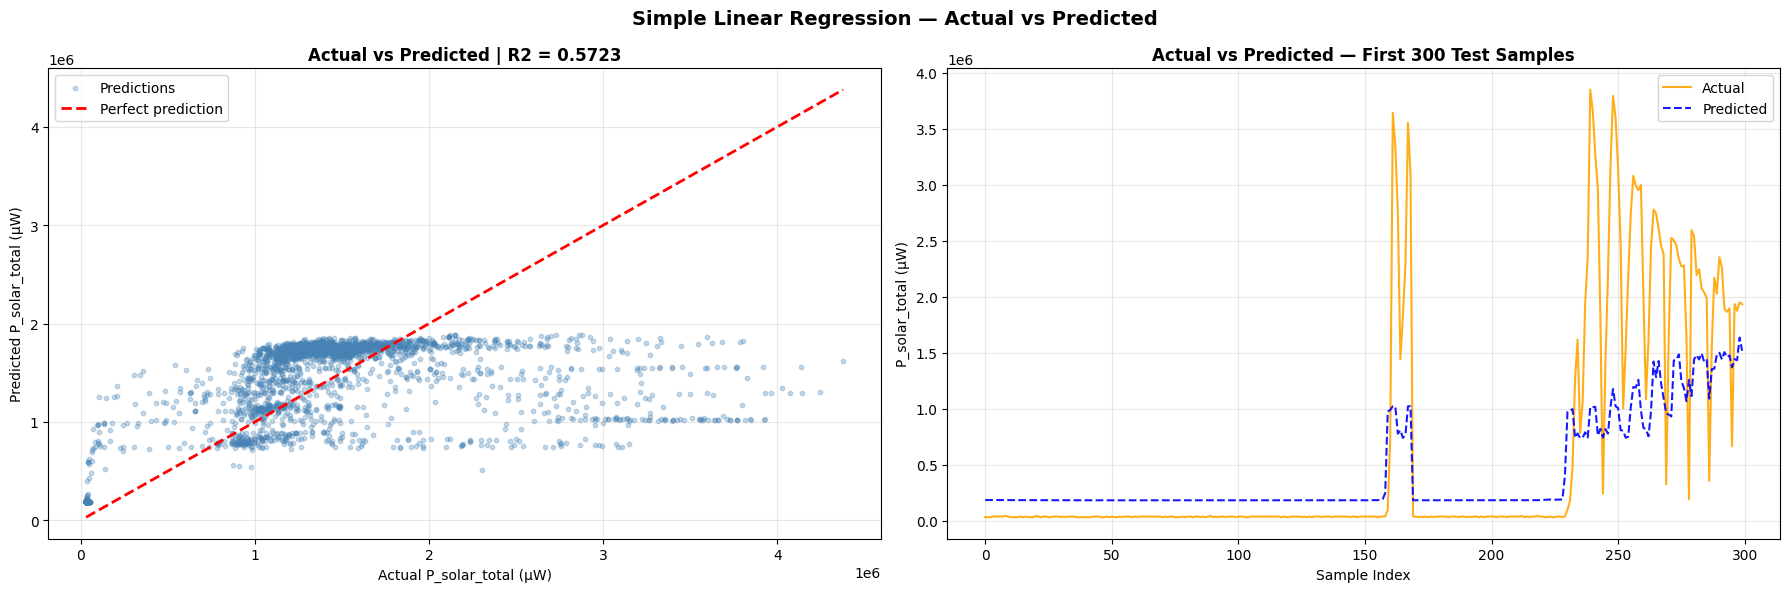

Plot 2 saved.


In [24]:
# --- Plot 2: Actual vs Predicted ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Simple Linear Regression — Actual vs Predicted',
             fontsize=14, fontweight='bold')

# Scatter actual vs predicted
axes[0].scatter(y_test_p, y_pred_p, color='steelblue',
                alpha=0.3, s=10, label='Predictions')
min_val = min(y_test_p.min(), y_pred_p.min())
max_val = max(y_test_p.max(), y_pred_p.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2, linestyle='--', label='Perfect prediction')
axes[0].set_xlabel('Actual P_solar_total (µW)')
axes[0].set_ylabel('Predicted P_solar_total (µW)')
axes[0].set_title(f'Actual vs Predicted | R2 = {results_after["Primary"]["R2"]:.4f}',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# First 300 test samples overlay
axes[1].plot(range(300), y_test_p.values[:300],
             color='orange', linewidth=1.5, label='Actual', alpha=0.9)
axes[1].plot(range(300), y_pred_p[:300],
             color='blue', linewidth=1.5, label='Predicted',
             linestyle='--', alpha=0.9)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('P_solar_total (µW)')
axes[1].set_title('Actual vs Predicted — First 300 Test Samples', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved.")

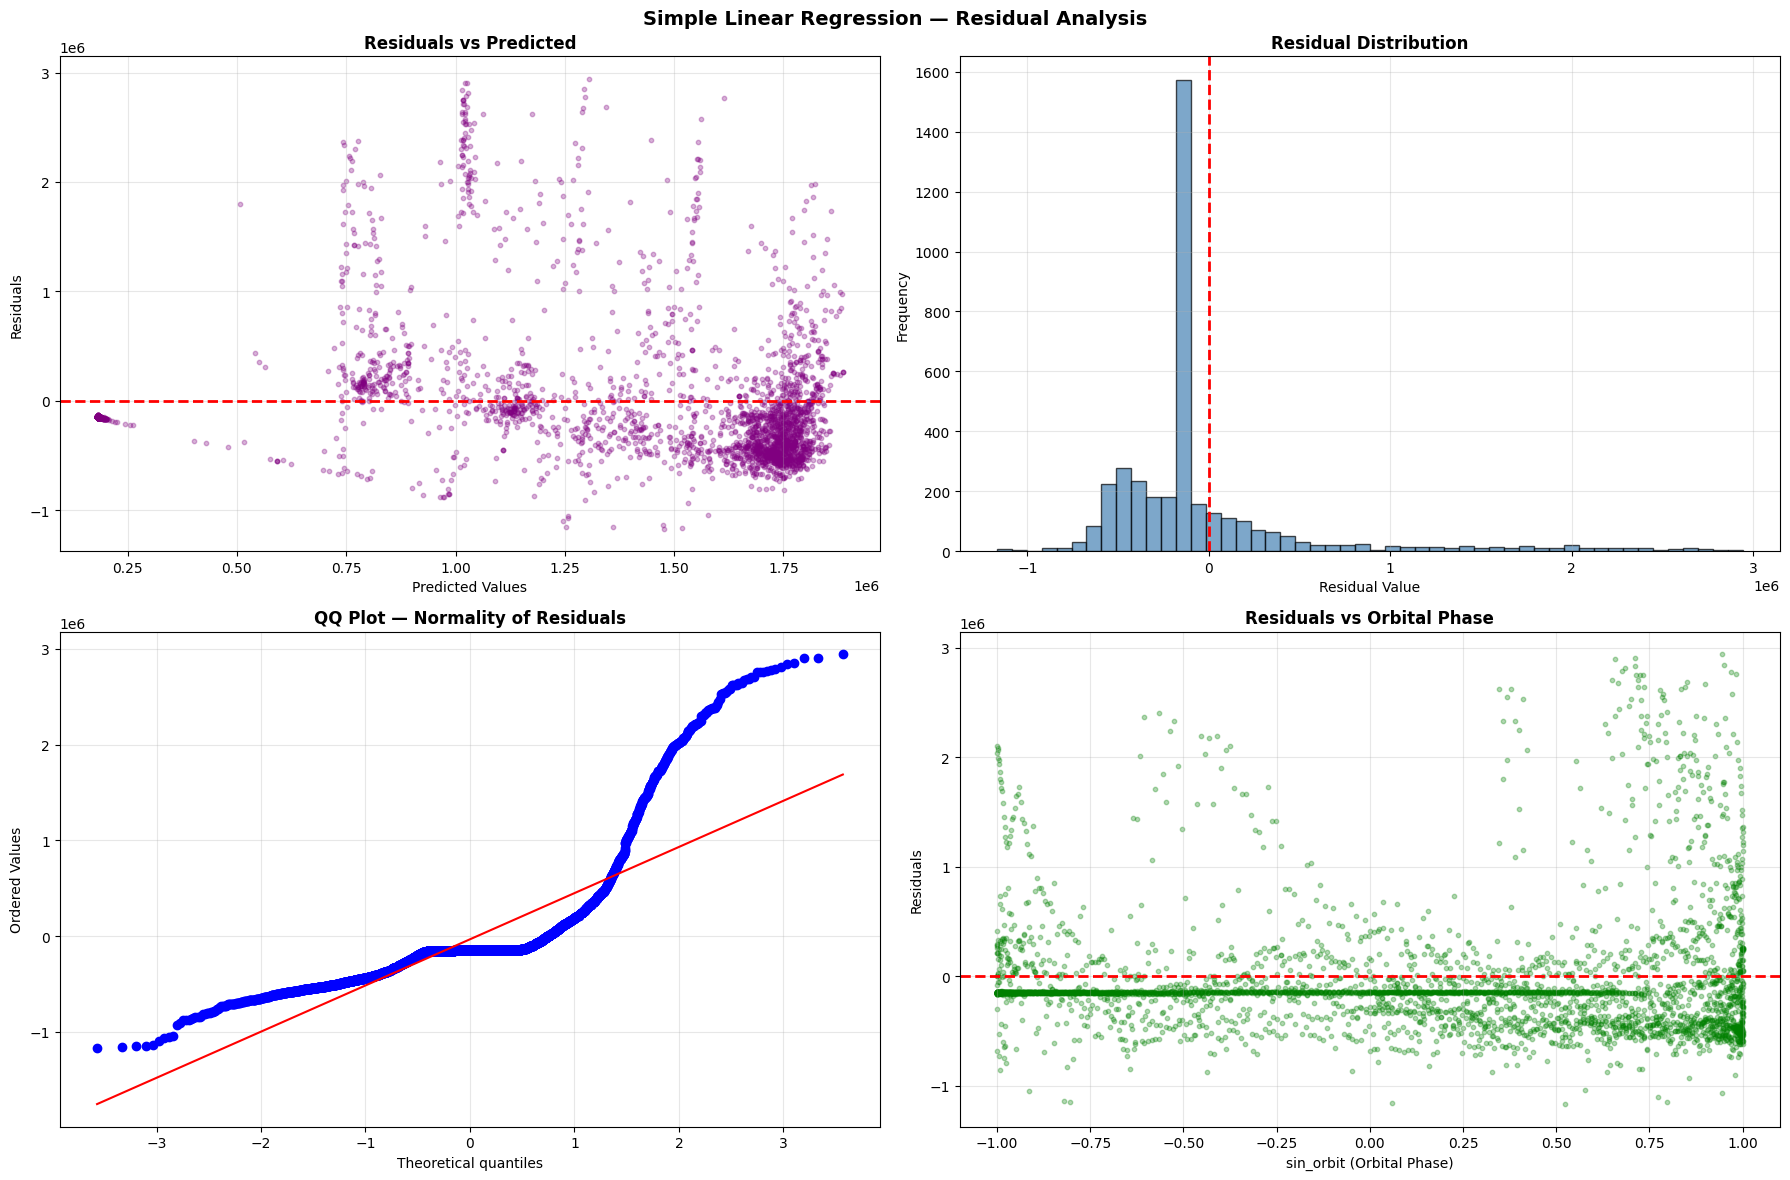

Plot 3 saved.


In [25]:
# --- Plot 3: Residual Analysis ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Simple Linear Regression — Residual Analysis',
             fontsize=14, fontweight='bold')

# Residuals vs Predicted
axes[0,0].scatter(y_pred_p, residuals_p, color='purple',
                  alpha=0.3, s=10)
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Predicted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Residual Distribution
axes[0,1].hist(residuals_p, bins=50, color='steelblue',
               edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Residual Value')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Residual Distribution', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# QQ Plot
stats.probplot(residuals_p, dist='norm', plot=axes[1,0])
axes[1,0].set_title('QQ Plot — Normality of Residuals', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# Residuals vs Orbital Phase
orbit_phase = df['sin_orbit'].iloc[test_idx].values
axes[1,1].scatter(orbit_phase, residuals_p, color='green',
                  alpha=0.3, s=10)
axes[1,1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_xlabel('sin_orbit (Orbital Phase)')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Residuals vs Orbital Phase', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved.")

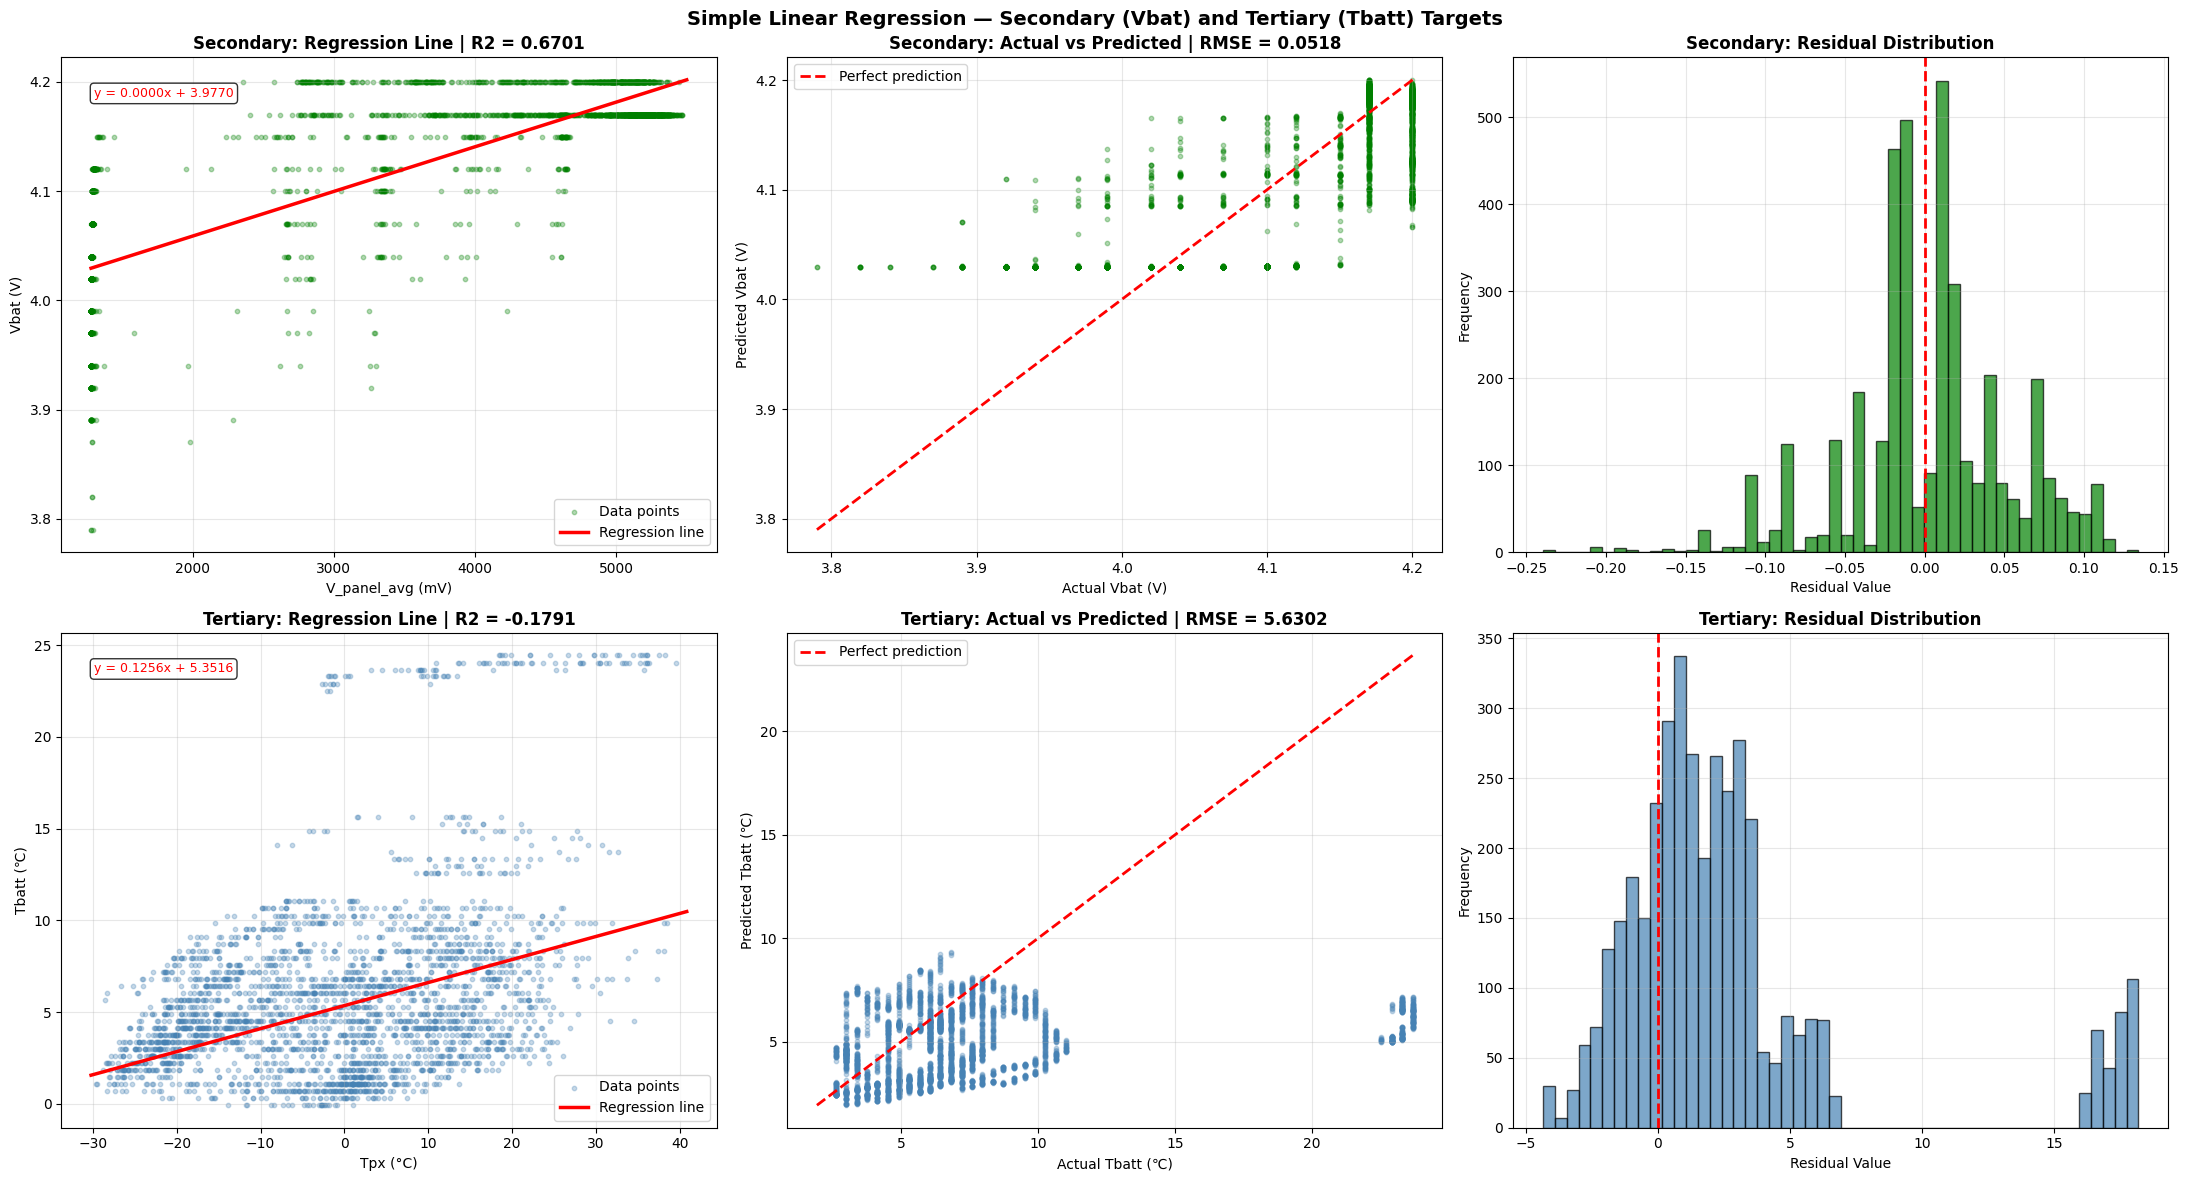

Plot 4 saved.


In [26]:
# ============================================================
# SECTION 7: SECONDARY AND TERTIARY TARGET VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Simple Linear Regression — Secondary (Vbat) and Tertiary (Tbatt) Targets',
             fontsize=14, fontweight='bold')

targets_info = {
    'Secondary': {
        'X_col'  : X_SECONDARY,
        'y_col'  : TARGET_SECONDARY,
        'color'  : 'green',
        'row'    : 0
    },
    'Tertiary': {
        'X_col'  : X_TERTIARY,
        'y_col'  : TARGET_TERTIARY,
        'color'  : 'steelblue',
        'row'    : 1
    }
}

for name, info in targets_info.items():
    X   = df[[info['X_col']]]
    y   = df[info['y_col']]
    row = info['row']
    clr = info['color']

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    model   = best_models[name][0]
    y_pred  = best_models[name][1]
    resids  = y_test.values - y_pred
    r2      = results_after[name]['R2']
    rmse    = results_after[name]['RMSE']

    # Plot 1: Regression line
    sample = df.sample(3000, random_state=42)
    axes[row, 0].scatter(sample[info['X_col']], sample[info['y_col']],
                         color=clr, alpha=0.3, s=10, label='Data points')
    x_line = np.linspace(X.min().values[0], X.max().values[0], 300).reshape(-1,1)
    y_line = model.predict(x_line)
    axes[row, 0].plot(x_line, y_line, color='red', linewidth=2.5, label='Regression line')
    coef  = model.coef_[0]
    inter = model.intercept_
    axes[row, 0].annotate(f'y = {coef:.4f}x + {inter:.4f}',
                          xy=(0.05, 0.92), xycoords='axes fraction',
                          fontsize=9, color='red',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[row, 0].set_xlabel(info['X_col'])
    axes[row, 0].set_ylabel(info['y_col'])
    axes[row, 0].set_title(f'{name}: Regression Line | R2 = {r2:.4f}', fontweight='bold')
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    # Plot 2: Actual vs Predicted
    axes[row, 1].scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[row, 1].plot([min_val, max_val], [min_val, max_val],
                      color='red', linewidth=2, linestyle='--', label='Perfect prediction')
    axes[row, 1].set_xlabel(f'Actual {info["y_col"]}')
    axes[row, 1].set_ylabel(f'Predicted {info["y_col"]}')
    axes[row, 1].set_title(f'{name}: Actual vs Predicted | RMSE = {rmse:.4f}',
                           fontweight='bold')
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

    # Plot 3: Residual distribution
    axes[row, 2].hist(resids, bins=50, color=clr,
                      edgecolor='black', alpha=0.7)
    axes[row, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[row, 2].set_xlabel('Residual Value')
    axes[row, 2].set_ylabel('Frequency')
    axes[row, 2].set_title(f'{name}: Residual Distribution', fontweight='bold')
    axes[row, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_secondary_tertiary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved.")

## Secondary (Vbat)

The regression line equation shows:

> y = 0.0000x + 3.9770

The coefficient is essentially zero, meaning **V_panel_avg alone is not capturing Vbat variation well despite R² = 0.67**.

The quantized / stepped pattern in actual vs predicted reveals the sensor measures in discrete steps.

---

## Tertiary (Tbatt)

**R² = -0.179 confirmed** — the model is completely failing.

The actual vs predicted scatter shows predictions clustered in a narrow band  
while actual values spread widely.

---

## Cross Validation Confirmation

- **P_solar_total:** stable across folds (**0.53–0.62**), consistent model  
- **Vbat:** stable (**0.63–0.72**), reliable  
- **Tbatt:** wildly unstable (**-1.44 to +0.19**), model is meaningless for this target  

5-FOLD TIMESERIES CROSS VALIDATION RESULTS

Target  : P_solar_total (µW)
Fold R2 scores : [np.float64(0.6251), np.float64(0.5344), np.float64(0.5655), np.float64(0.5495), np.float64(0.5723)]
Mean R2        : 0.5694
Std Dev        : 0.0308
Min R2         : 0.5344
Max R2         : 0.6251

Target  : Vbat (V)
Fold R2 scores : [np.float64(0.7227), np.float64(0.6351), np.float64(0.6855), np.float64(0.7187), np.float64(0.6701)]
Mean R2        : 0.6864
Std Dev        : 0.0324
Min R2         : 0.6351
Max R2         : 0.7227

Target  : Tbatt (℃)
Fold R2 scores : [np.float64(-1.44), np.float64(0.1927), np.float64(-0.4253), np.float64(-0.7059), np.float64(-0.1791)]
Mean R2        : -0.5115
Std Dev        : 0.5502
Min R2         : -1.4400
Max R2         : 0.1927


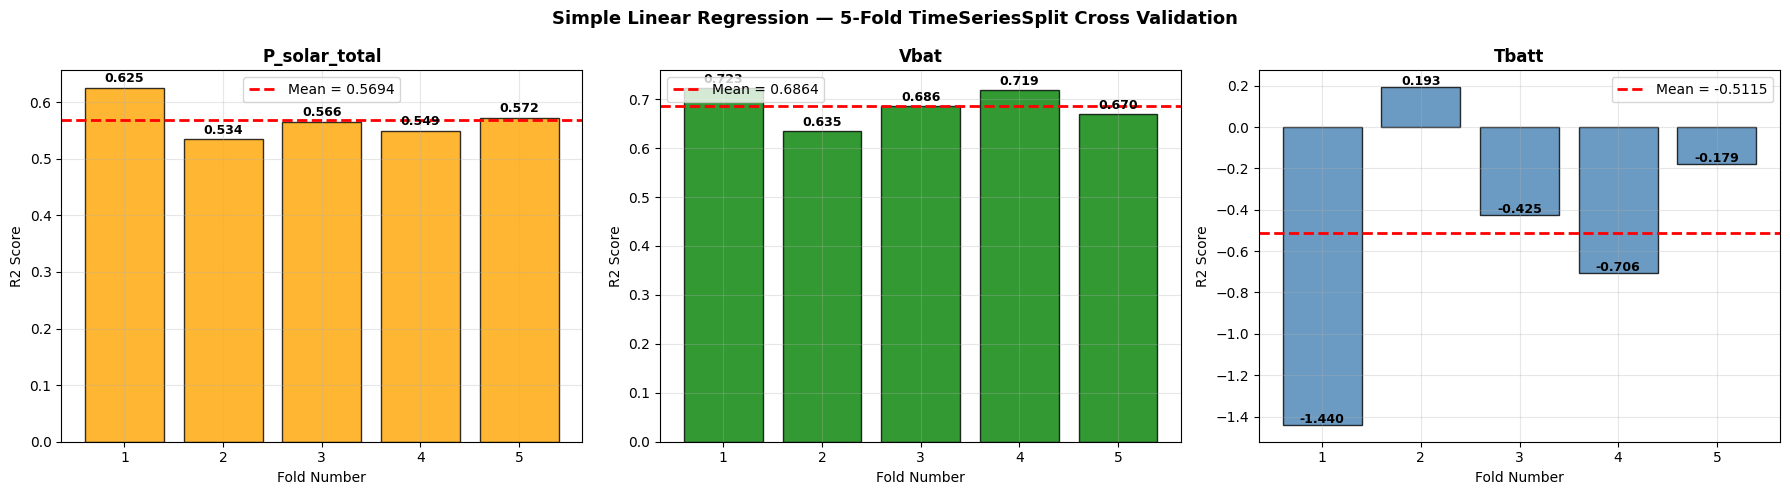


Cross validation plot saved.


In [27]:
# ============================================================
# SECTION 8: CROSS VALIDATION
# ============================================================

print("=" * 55)
print("5-FOLD TIMESERIES CROSS VALIDATION RESULTS")
print("=" * 55)

cv_results = {}

for name, (X, y) in datasets.items():
    model  = LinearRegression(**best_models[name][0].get_params())
    scores = cross_val_score(model, X, y,
                             cv=tscv,
                             scoring='r2')

    cv_results[name] = scores
    print(f"\nTarget  : {y.name}")
    print(f"Fold R2 scores : {[round(s, 4) for s in scores]}")
    print(f"Mean R2        : {scores.mean():.4f}")
    print(f"Std Dev        : {scores.std():.4f}")
    print(f"Min R2         : {scores.min():.4f}")
    print(f"Max R2         : {scores.max():.4f}")

# Plot cross validation scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Simple Linear Regression — 5-Fold TimeSeriesSplit Cross Validation',
             fontsize=13, fontweight='bold')

colors = ['orange', 'green', 'steelblue']
target_names = ['P_solar_total', 'Vbat', 'Tbatt']

for idx, (name, scores) in enumerate(cv_results.items()):
    ax = axes[idx]
    bars = ax.bar(range(1, 6), scores,
                  color=colors[idx], edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean = {scores.mean():.4f}')
    ax.set_title(f'{target_names[idx]}', fontweight='bold')
    ax.set_xlabel('Fold Number')
    ax.set_ylabel('R2 Score')
    ax.set_xticks(range(1, 6))
    ax.legend()
    ax.grid(True, alpha=0.3)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('05_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCross validation plot saved.")

In [28]:
# ============================================================
# SECTION 9: BEFORE vs AFTER TUNING COMPARISON TABLE
# ============================================================

print("=" * 75)
print("SIMPLE LINEAR REGRESSION — COMPLETE RESULTS SUMMARY")
print("=" * 75)

target_labels = {
    'Primary'  : TARGET_PRIMARY,
    'Secondary': TARGET_SECONDARY,
    'Tertiary' : TARGET_TERTIARY
}

for name in ['Primary', 'Secondary', 'Tertiary']:
    b = results_before[name]
    a = results_after[name]
    cv = cv_results[name]

    r2_change   = ((a['R2']   - b['R2'])   / abs(b['R2'])   * 100) if b['R2'] != 0 else 0
    rmse_change = ((a['RMSE'] - b['RMSE']) / abs(b['RMSE']) * 100)

    print(f"\nTarget: {target_labels[name]}")
    print(f"{'Metric':<10} {'Before Tuning':>15} {'After Tuning':>15} {'Change':>10}")
    print("-" * 55)
    print(f"{'R2':<10} {b['R2']:>15.4f} {a['R2']:>15.4f} {r2_change:>+9.2f}%")
    print(f"{'RMSE':<10} {b['RMSE']:>15.4f} {a['RMSE']:>15.4f} {rmse_change:>+9.2f}%")
    print(f"{'MAE':<10} {b['MAE']:>15.4f} {a['MAE']:>15.4f}")
    print(f"{'MSE':<10} {b['MSE']:>15.4f} {a['MSE']:>15.4f}")
    print(f"CV Mean R2  : {cv.mean():.4f} +/- {cv.std():.4f}")
    print(f"Best Params : {best_models[name][0].get_params()}")

# ============================================================
# SECTION 10: UNIQUE ANALYSIS — DURBIN WATSON TEST
# ============================================================

print("\n" + "=" * 75)
print("UNIQUE ANALYSIS — DURBIN WATSON TEST FOR AUTOCORRELATION")
print("=" * 75)
print("Durbin Watson statistic interpretation:")
print("  ~2.0 = No autocorrelation (ideal)")
print("  <1.5 = Positive autocorrelation (residuals are correlated)")
print("  >2.5 = Negative autocorrelation")
print()

from statsmodels.stats.stattools import durbin_watson

target_names_dw = {
    'Primary'  : TARGET_PRIMARY,
    'Secondary': TARGET_SECONDARY,
    'Tertiary' : TARGET_TERTIARY
}

for name in ['Primary', 'Secondary', 'Tertiary']:
    X   = datasets[name][0]
    y   = datasets[name][1]
    model = best_models[name][0]
    y_pred = best_models[name][1]
    y_test = y.iloc[test_idx]
    resids = y_test.values - y_pred
    dw = durbin_watson(resids)

    if dw < 1.5:
        interpretation = "Positive autocorrelation — model missing temporal patterns"
    elif dw > 2.5:
        interpretation = "Negative autocorrelation"
    else:
        interpretation = "No significant autocorrelation"

    print(f"Target : {target_names_dw[name]}")
    print(f"DW Stat: {dw:.4f} — {interpretation}")
    print()

SIMPLE LINEAR REGRESSION — COMPLETE RESULTS SUMMARY

Target: P_solar_total (µW)
Metric       Before Tuning    After Tuning     Change
-------------------------------------------------------
R2                  0.5723          0.5723     +0.00%
RMSE           579059.9313     579059.9313     +0.00%
MAE            369745.4891     369745.4891
MSE        335310404066.0654 335310404066.0654
CV Mean R2  : 0.5694 +/- 0.0308
Best Params : {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': True}

Target: Vbat (V)
Metric       Before Tuning    After Tuning     Change
-------------------------------------------------------
R2                  0.6701          0.6701     +0.00%
RMSE                0.0518          0.0518     +0.00%
MAE                 0.0389          0.0389
MSE                 0.0027          0.0027
CV Mean R2  : 0.6864 +/- 0.0324
Best Params : {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': True}

Target: Tbatt (℃)
Metric       Before Tuning    A

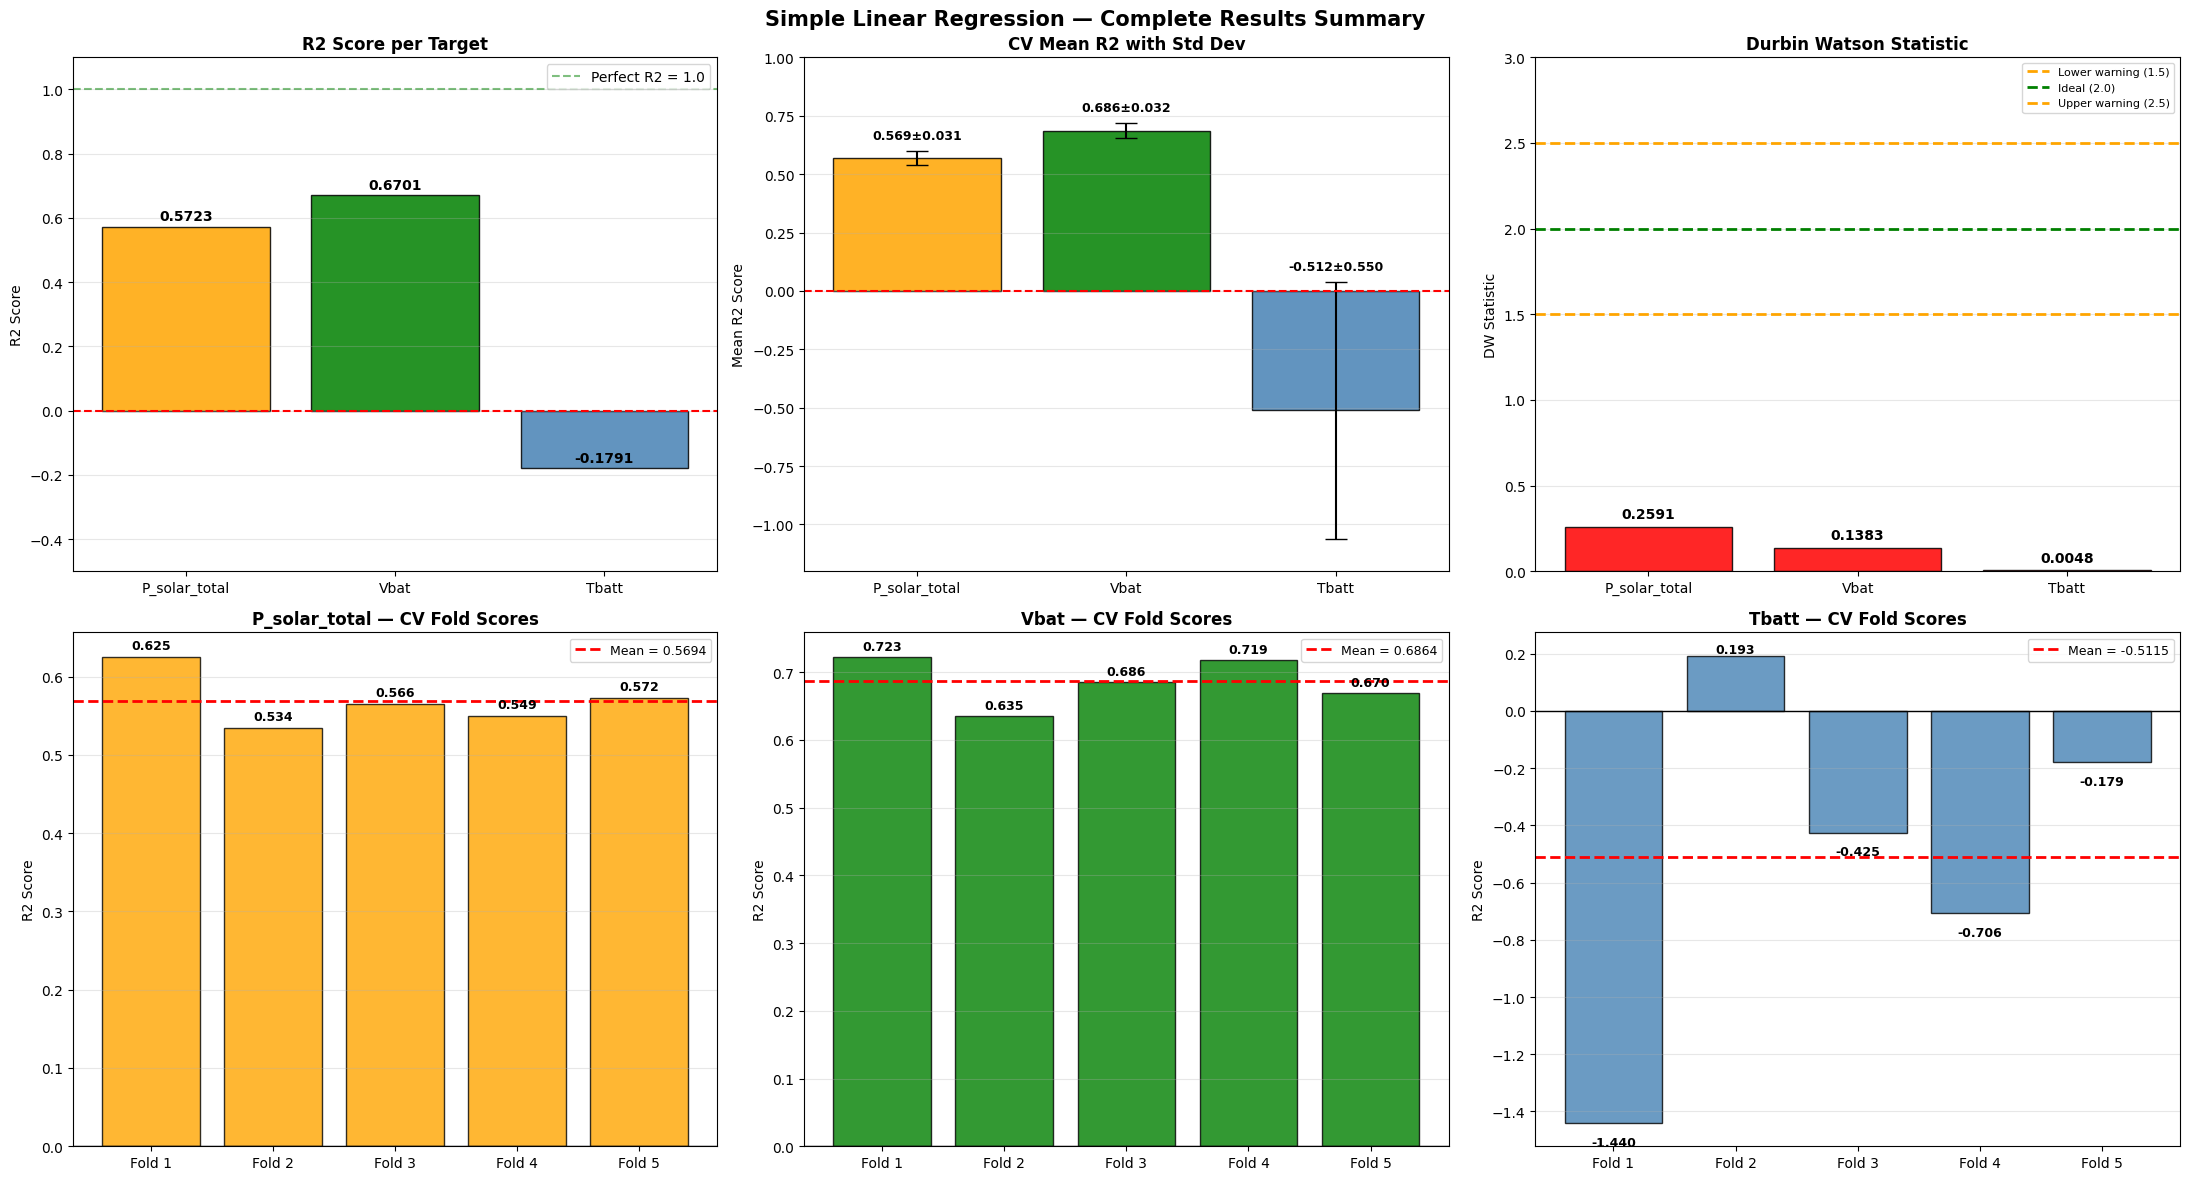

Final summary plot saved.


In [29]:
# ============================================================
# SECTION 11: FINAL SUMMARY VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Simple Linear Regression — Complete Results Summary',
             fontsize=15, fontweight='bold')

target_names_list = ['P_solar_total', 'Vbat', 'Tbatt']
colors = ['orange', 'green', 'steelblue']
metrics = ['R2', 'RMSE', 'MAE']

# Row 1: Metrics comparison bar chart for all 3 targets
r2_vals   = [results_after[n]['R2']   for n in ['Primary','Secondary','Tertiary']]
rmse_vals = [results_after[n]['RMSE'] for n in ['Primary','Secondary','Tertiary']]
mae_vals  = [results_after[n]['MAE']  for n in ['Primary','Secondary','Tertiary']]
cv_means  = [cv_results[n].mean()     for n in ['Primary','Secondary','Tertiary']]
cv_stds   = [cv_results[n].std()      for n in ['Primary','Secondary','Tertiary']]

# Plot 1: R2 comparison
bars = axes[0,0].bar(target_names_list, r2_vals,
                     color=colors, edgecolor='black', alpha=0.85)
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].axhline(y=1, color='green', linestyle='--',
                  linewidth=1.5, alpha=0.5, label='Perfect R2 = 1.0')
axes[0,0].set_title('R2 Score per Target', fontweight='bold')
axes[0,0].set_ylabel('R2 Score')
axes[0,0].set_ylim([-0.5, 1.1])
for bar, val in zip(bars, r2_vals):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.02,
                   f'{val:.4f}', ha='center',
                   fontsize=10, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3, axis='y')

# Plot 2: Cross validation R2 with error bars
axes[0,1].bar(target_names_list, cv_means,
              color=colors, edgecolor='black', alpha=0.85,
              yerr=cv_stds, capsize=8)
axes[0,1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].set_title('CV Mean R2 with Std Dev', fontweight='bold')
axes[0,1].set_ylabel('Mean R2 Score')
axes[0,1].set_ylim([-1.2, 1.0])
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    axes[0,1].text(i, mean + std + 0.05,
                   f'{mean:.3f}±{std:.3f}',
                   ha='center', fontsize=9, fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='y')

# Plot 3: Durbin Watson statistics
dw_vals = [0.2591, 0.1383, 0.0048]
bar_colors_dw = ['red' if d < 1.5 else 'green' for d in dw_vals]
bars_dw = axes[0,2].bar(target_names_list, dw_vals,
                         color=bar_colors_dw, edgecolor='black', alpha=0.85)
axes[0,2].axhline(y=1.5, color='orange', linestyle='--',
                  linewidth=2, label='Lower warning (1.5)')
axes[0,2].axhline(y=2.0, color='green', linestyle='--',
                  linewidth=2, label='Ideal (2.0)')
axes[0,2].axhline(y=2.5, color='orange', linestyle='--',
                  linewidth=2, label='Upper warning (2.5)')
axes[0,2].set_title('Durbin Watson Statistic', fontweight='bold')
axes[0,2].set_ylabel('DW Statistic')
axes[0,2].set_ylim([0, 3])
for bar, val in zip(bars_dw, dw_vals):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.4f}', ha='center',
                   fontsize=10, fontweight='bold')
axes[0,2].legend(fontsize=8)
axes[0,2].grid(True, alpha=0.3, axis='y')

# Row 2: CV fold scores for each target
fold_labels = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
for idx, (name, color, tname) in enumerate(zip(
        ['Primary','Secondary','Tertiary'], colors, target_names_list)):
    ax  = axes[1, idx]
    scores = cv_results[name]
    bars = ax.bar(fold_labels, scores,
                  color=color, edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean = {scores.mean():.4f}')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_title(f'{tname} — CV Fold Scores', fontweight='bold')
    ax.set_ylabel('R2 Score')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, scores):
        ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.08
        ax.text(bar.get_x() + bar.get_width()/2,
                ypos, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('06_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final summary plot saved.")

# SIMPLE LINEAR REGRESSION — CONCLUSION  
### Dataset: TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)

---

## ALGORITHM SUMMARY

Simple Linear Regression fits a straight line **y = mx + b** using  
Ordinary Least Squares (OLS) minimization. It uses exactly one  
input feature to predict one target variable.

---

## FEATURE SELECTION JUSTIFICATION

Features were selected based on highest absolute correlation with  
each target, determined from EDA (refer *01_EDA.ipynb*):

- **V_panel_avg (mV)** for **P_solar_total** → corr = **0.758**  
- **V_panel_avg (mV)** for **Vbat** → corr = **0.832**  
- **Tpx (°C)** for **Tbatt** → corr = **0.363**

---

## RESULTS SUMMARY

| Target         | R²       | CV Mean R² | DW Stat | Verdict  |
|---------------|----------|------------|---------|----------|
| P_solar_total | 0.5723   | 0.5694     | 0.2591  | Moderate |
| Vbat          | 0.6701   | 0.6864     | 0.1383  | Moderate |
| Tbatt         | -0.1791  | -0.5115    | 0.0048  | Failed   |

---

## HYPERPARAMETER TUNING

GridSearchCV tested **fit_intercept** and **positive** parameters.  
Best configuration for all targets:  
**fit_intercept = True, positive = True**

Metrics remained unchanged — confirming default settings were already  
optimal for this algorithm, which is expected for Simple Linear  
Regression as it has very limited tuning parameters.

---

## KEY FINDINGS

**1. P_solar_total (R² = 0.57)**  
Single voltage feature captures moderate variance.  
The OLS equation:

> **y = 408.25x − 343189.66**

shows each **1 mV** increase in average panel voltage corresponds to  
**408.25 µW** increase in solar power generation — physically meaningful relationship.

**2. Vbat (R² = 0.67)**  
Best performing target for this model. Battery voltage shows stronger  
linear relationship with panel voltage, reflecting the direct charging  
effect during sunlight periods.

**3. Tbatt (R² = -0.179)**  
Complete model failure. Battery temperature is governed by internal  
heat dissipation and thermal inertia rather than panel sensor readings.  
This confirms thermal dynamics require more complex non-linear models.

---

## DURBIN–WATSON ANALYSIS

All three targets show DW statistics close to **0** (range **0.005–0.259**),  
indicating strong positive autocorrelation in residuals. This means  
the model is missing the temporal orbital cycling patterns in the data.

This is a fundamental limitation of Simple Linear Regression on  
time-series satellite telemetry — it treats each sample independently  
and cannot capture the **92.6-minute orbital periodicity**.

---

### Reference  
Jara et al. (2022), *Data in Brief*  
DOI: 10.1016/j.dib.2022.108697